# House Sales Data Analysis – Exploratory Data Analysis (EDA)

**Objective**: Load, clean, and explore a real-estate dataset to uncover pricing trends and feature relationships.

**Key improvements**:
- Consistent variable naming (`df_house`).
- Professional chart styling (`sns.set_theme`).
- Clear titles, axis labels, and figure legends.
- Structured workflow with descriptive Markdown headers.

In [158]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, professional style suitable for scientific publications
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

## 1. Data Loading and Initial Inspection

In [159]:
# Load dataset
df_house = pd.read_csv('../data/house_sales.csv')

print("Dataset shape:", df_house.shape)
print("\nColumn names:")
print(df_house.columns.tolist())
df_house.head()

Dataset shape: (106118, 12)

Column names:
['city', 'address', 'area', 'floor', 'name', 'price', 'province', 'rooms', 'toward', 'unit', 'year', 'origin_url']


,city,address,area,floor,name,price,province,rooms,toward,unit,year,origin_url
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90㎡,中层（共18层）,圣地亚哥,128万,安徽,3室2厅,南北向,14222元/㎡,2013年建,https://hf.esf.fang.com/chushou/3_404230646.htm
1,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90㎡,中层（共18层）,圣地亚哥,128万,安徽,3室2厅,南北向,14222元/㎡,2013年建,https://hf.esf.fang.com/chushou/3_404230646.htm
2,合肥,生态公园-淮海大道与大众路交口,95㎡,中层（共18层）,正荣·悦都荟,132万,安徽,3室2厅,南向,13895元/㎡,2019年建,https://hf.esf.fang.com/chushou/3_404304901.htm
3,合肥,生态公园-淮海大道与大众路交口,95㎡,中层（共18层）,正荣·悦都荟,132万,安徽,3室2厅,南向,13895元/㎡,2019年建,https://hf.esf.fang.com/chushou/3_404304901.htm
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37㎡,中层（共22层）,文一名门金隅,32万,安徽,2室1厅,南北向,8649元/㎡,2017年建,https://hf.esf.fang.com/chushou/3_404372096.htm


In [160]:
df_house.info()

<class 'pandas.DataFrame'>
RangeIndex: 106118 entries, 0 to 106117
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   city        106118 non-null  str  
 1   address     104452 non-null  str  
 2   area        105324 non-null  str  
 3   floor       104024 non-null  str  
 4   name        105564 non-null  str  
 5   price       105564 non-null  str  
 6   province    106118 non-null  str  
 7   rooms       104036 non-null  str  
 8   toward      105240 non-null  str  
 9   unit        105564 non-null  str  
 10  year        57736 non-null   str  
 11  origin_url  105564 non-null  str  
dtypes: str(12)
memory usage: 9.7 MB


## 2. Data Cleaning

In [161]:
# Drop irrelevant column
df_house.drop(columns='origin_url', inplace=True)

# Check missing values
print("Missing values per column before cleaning:")
print(df_house.isna().sum())

# Drop rows with any missing value
df_house.dropna(inplace=True)
print(f"\nRows after dropping NaN: {len(df_house)}")

# Remove duplicate rows
df_house.drop_duplicates(inplace=True)
print(f"Rows after removing duplicates: {len(df_house)}")

Missing values per column before cleaning:
city            0
address      1666
area          794
floor        2094
name          554
price         554
province        0
rooms        2082
toward        878
unit          554
year        48382
dtype: int64

Rows after dropping NaN: 57520
Rows after removing duplicates: 28104


In [162]:
# Clean 'area': remove '㎡' and convert to float
df_house['area'] = df_house['area'].str.replace('㎡', '').astype(float)

# Clean 'price': remove '万' and convert to float
df_house['price'] = df_house['price'].str.replace('万', '').astype(float)

# Clean 'unit': remove '元/㎡' and convert to float
df_house['unit'] = df_house['unit'].str.replace('元/㎡', '').astype(float)

# Clean 'year': remove '年建' and convert to float
df_house['year'] = df_house['year'].str.replace('年建', '').astype(float)

# Convert 'toward' to categorical type
df_house['toward'] = df_house['toward'].astype('category')

print("Data types after conversion:")
df_house.info()

Data types after conversion:
<class 'pandas.DataFrame'>
Index: 28104 entries, 0 to 106088
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   city      28104 non-null  str     
 1   address   28104 non-null  str     
 2   area      28104 non-null  float64 
 3   floor     28104 non-null  str     
 4   name      28104 non-null  str     
 5   price     28104 non-null  float64 
 6   province  28104 non-null  str     
 7   rooms     28104 non-null  str     
 8   toward    28104 non-null  category
 9   unit      28104 non-null  float64 
 10  year      28104 non-null  float64 
dtypes: category(1), float64(4), str(6)
memory usage: 2.4 MB


In [163]:
# Keep only houses with area between 20 and 600 sqm (reasonable range)
df_house = df_house[(df_house['area'] > 20) & (df_house['area'] < 600)]
print(f"Rows after filtering area: {len(df_house)}")

Rows after filtering area: 28079


In [164]:
df_house.head()

,city,address,area,floor,name,price,province,rooms,toward,unit,year
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90.0,中层（共18层）,圣地亚哥,128.0,安徽,3室2厅,南北向,14222.0,2013.0
2,合肥,生态公园-淮海大道与大众路交口,95.0,中层（共18层）,正荣·悦都荟,132.0,安徽,3室2厅,南向,13895.0,2019.0
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37.0,中层（共22层）,文一名门金隅,32.0,安徽,2室1厅,南北向,8649.0,2017.0
6,合肥,龙岗-长江东路与和县里交口,50.0,高层（共30层）,柏庄金座,46.0,安徽,2室1厅,南向,9200.0,2019.0
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120.0,中层（共27层）,天目未来,158.0,安徽,4室2厅,南向,13167.0,2012.0


## 3. Feature Engineering

In [165]:
# Extract district from address (first part before '-')
df_house['district'] = df_house['address'].str.split('-').str[0]

# Extract floor type (first part before '(')
df_house['floor_type'] = df_house['floor'].str.split('（').str[0]

# Define function to categorize floor level
def categorize_floor(floor_str):
    if pd.isna(floor_str):
        return 'not known'
    elif '低' in floor_str:
        return 'low'
    elif '中' in floor_str:
        return 'medium'
    elif '高' in floor_str:
        return 'high'
    else:
        return 'other'

df_house['floor_category'] = df_house['floor'].apply(categorize_floor).astype('category')

In [166]:
# Mark municipalities (直辖市)
municipalities = ['北京', '上海', '天津', '重庆']
df_house['is_municipality'] = df_house['city'].apply(lambda x: 1 if x in municipalities else 0)

# Extract living rooms and bedrooms from 'rooms' column
df_house['livingrooms'] = df_house['rooms'].str.extract(r'(\d+)厅').astype('int')
df_house['bedroom'] = df_house['rooms'].str.extract(r'(\d+)室').astype('int')

In [167]:
# Building age (assuming current year is 2025)
df_house['building_age'] = 2025 - df_house['year']

# Price categories (4 bins)
df_house['price_category'] = pd.cut(
    df_house['price'],
    bins=4,
    labels=['low', 'medium', 'high', 'very_high']
)

# Sample 5 rows to verify new features
df_house.sample(5)

,city,address,area,floor,name,price,province,rooms,toward,unit,year,district,floor_type,floor_category,is_municipality,livingrooms,bedroom,building_age,price_category
11462,沈阳,北行-皇姑区宁山中路138号,144.90,中层（共22层）,翔凤华园,208.0,辽宁,3室2厅,南北向,14355.0,2009.0,北行,中层,medium,0,2,3,16.0,low
47754,建德,钱江新城-钱江国际时代广场钱江新城富春路与城星路交叉口,30.32,中层（共27层）,钱江国际时代广场,76.0,浙江,2室2厅,南向,25066.0,2014.0,钱江新城,中层,medium,0,2,2,11.0,low
52266,迁安,远洋城-卫国路与裕华道交叉口南行,71.60,低层（共17层）,金港国际怡园,88.0,河北,2室1厅,西北向,12290.0,2009.0,远洋城,低层,low,0,1,2,16.0,low
64222,高陵,航天大道-航天大道与神舟四路交汇处东南角,90.25,高层（共24层）,富力城,132.0,陕西,2室2厅,西北向,14626.0,2014.0,航天大道,高层,high,0,2,2,11.0,low
56996,新泰,灵山大街-致富路与泮阳大街交汇处,53.00,低层（共6层）,英雄山小区,59.8,山东,2室1厅,南向,11283.0,2000.0,灵山大街,低层,low,0,1,2,25.0,low


## 4. Outlier Detection (Price)

In [168]:
Q1 = df_house['price'].quantile(0.25)
Q3 = df_house['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df_house[(df_house['price'] < lower_bound) | (df_house['price'] > upper_bound)]
print(f"Number of price outliers (based on IQR): {len(outliers)}")
print("\nSample of outliers:")
outliers.head()

Number of price outliers (based on IQR): 1944

Sample of outliers:


,city,address,area,floor,name,price,province,rooms,toward,unit,year,district,floor_type,floor_category,is_municipality,livingrooms,bedroom,building_age,price_category
100,合肥,和煦园-茨河路与界首路交口东北角,190.00,高层（共6层）,合肥唐宁府,358.0,安徽,5室3厅,南向,18842.0,2019.0,和煦园,高层,high,0,3,5,6.0,low
176,上海,武宁-东新路88弄,174.95,低层（共33层）,新湖明珠城,1280.0,直辖市,4室2厅,南向,73164.0,2008.0,武宁,低层,low,1,2,4,17.0,low
180,上海,西郊-淞虹路855弄,98.00,中层（共8层）,郁庭峰,655.0,直辖市,3室1厅,南向,66837.0,2002.0,西郊,中层,medium,1,1,3,23.0,low
190,合肥,和煦园-合肥唐宁府茨河路与界首路交口东北角,158.00,中层（共24层）,合肥唐宁府,370.0,安徽,4室2厅,南北向,23418.0,2019.0,和煦园,中层,medium,0,2,4,6.0,low
232,上海,徐汇滨江-海波花苑龙华西路31弄52-73号、龙华西路,84.08,低层（共6层）,海波花苑,570.0,直辖市,2室2厅,南向,67793.0,1997.0,徐汇滨江,低层,low,1,2,2,28.0,low


## 5. Exploratory Data Analysis (EDA)

### 5.1 Correlation Analysis

Correlation with price:
price           1.000000
unit            0.785327
area            0.470622
building_age    0.084991
Name: price, dtype: float64


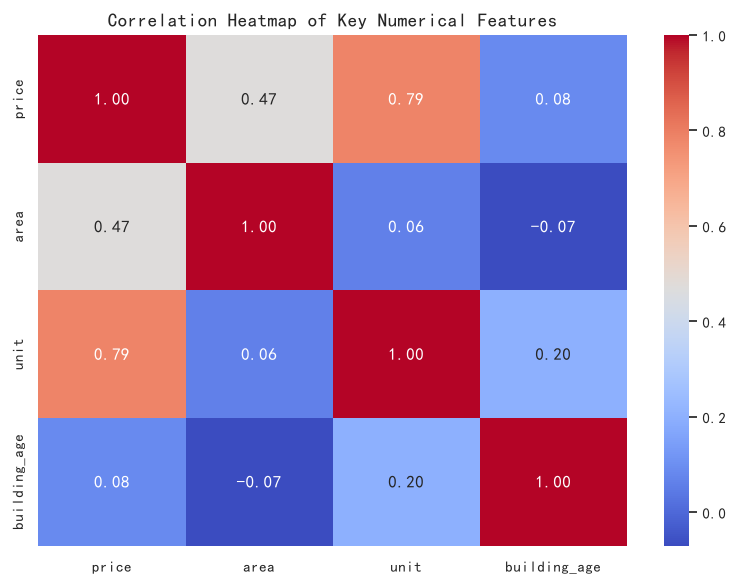

In [169]:
# Select numerical features for correlation
numeric_features = ['price', 'area', 'unit', 'building_age']
corr_matrix = df_house[numeric_features].corr()

print("Correlation with price:")
print(corr_matrix['price'].sort_values(ascending=False))

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Key Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

### 5.2 Price Distribution

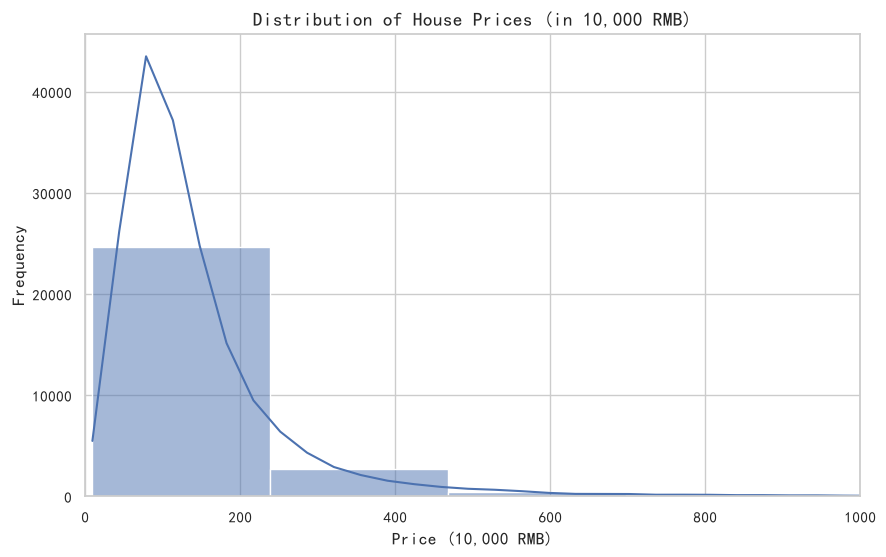

In [170]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_house, x='price', bins=30, kde=True)
plt.xlim(0, 1000)  # Focus on main range
plt.title('Distribution of House Prices (in 10,000 RMB)', fontsize=14)
plt.xlabel('Price (10,000 RMB)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

In [171]:
df_house[['price', 'area', 'unit', 'building_age', 'livingrooms', 'bedroom']].describe()

,price,area,unit,building_age,livingrooms,bedroom
count,28079.000000,28079.000000,28079.000000,28079.000000,28079.000000,28079.000000
mean,147.541519,107.829038,13429.487553,12.075537,1.857687,2.770398
std,173.377815,41.189153,10920.563531,6.117544,0.411881,0.845008
min,9.000000,21.000000,1000.000000,2.000000,0.000000,0.000000
25%,74.000000,86.000000,7779.500000,8.000000,2.000000,2.000000
50%,109.000000,101.400000,10833.000000,10.000000,2.000000,3.000000
75%,167.000000,126.000000,15396.000000,15.000000,2.000000,3.000000
max,6899.000000,588.000000,456311.000000,95.000000,12.000000,9.000000


### 5.3 Categorical Analysis: Orientation (朝向)

In [172]:
print("Orientation value counts:")
print(df_house['toward'].value_counts())

Orientation value counts:
toward
南北向    15936
南向      9395
东南向     1111
东向       446
西南向      308
北向       276
西向       182
东西向      162
西北向      138
东北向      125
Name: count, dtype: int64


In [173]:
grouped = df_house.groupby('toward').agg({
    'price': ['mean', 'median'],
    'unit': 'median',
    'building_age': 'mean'
})
grouped

price             unit building_age
              mean  median   median         mean
toward                                          
东北向     185.842480  109.88  12993.0    13.432000
东南向     177.744554  116.00  11950.0    11.531053
东向      136.787982  100.00  11786.0    12.838565
东西向     124.032099   86.40   9432.0    15.425926
北向      120.377536   80.90  12000.0    13.271739
南北向     148.572904  110.00  10358.0    12.219064
南向      140.854862  108.00  11250.0    11.628419
西北向     146.045725  108.00  12555.0    13.471014
西南向     223.074026  156.00  15052.0    14.220779
西向      153.508956   95.90  13431.0    13.626374

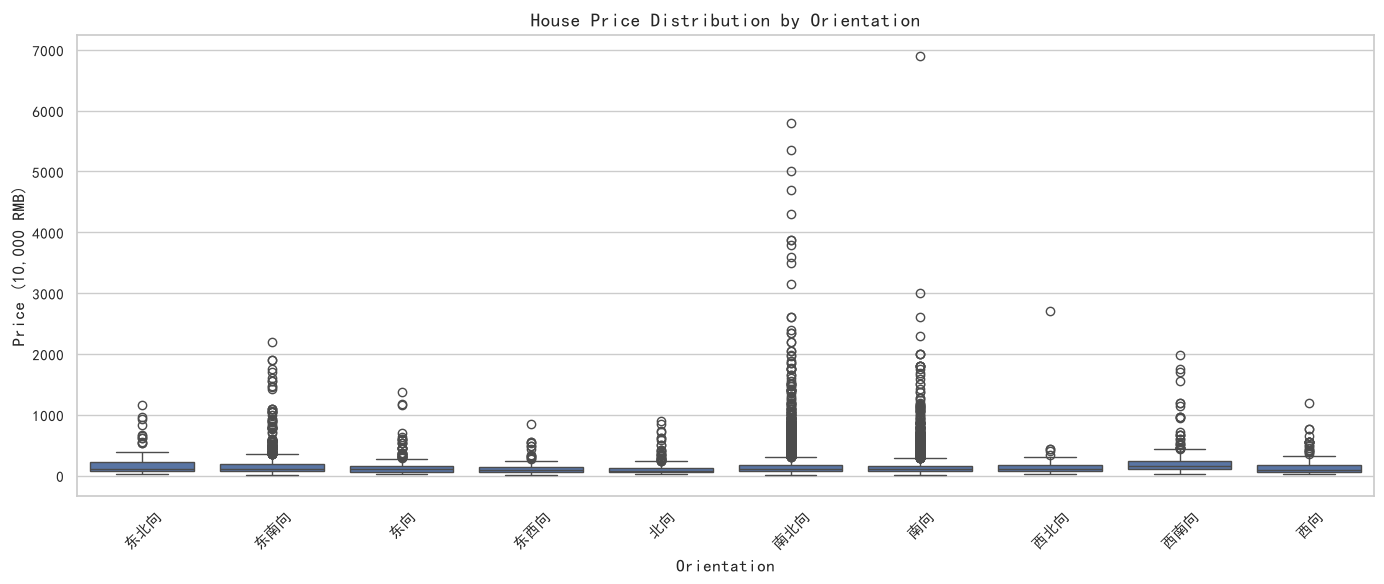

In [174]:
plt.figure(figsize=(14, 6))
sns.boxplot(x='toward', y='price', data=df_house)
plt.title('House Price Distribution by Orientation', fontsize=14)
plt.xlabel('Orientation', fontsize=12)
plt.ylabel('Price (10,000 RMB)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 5.4 Pairwise Relationships

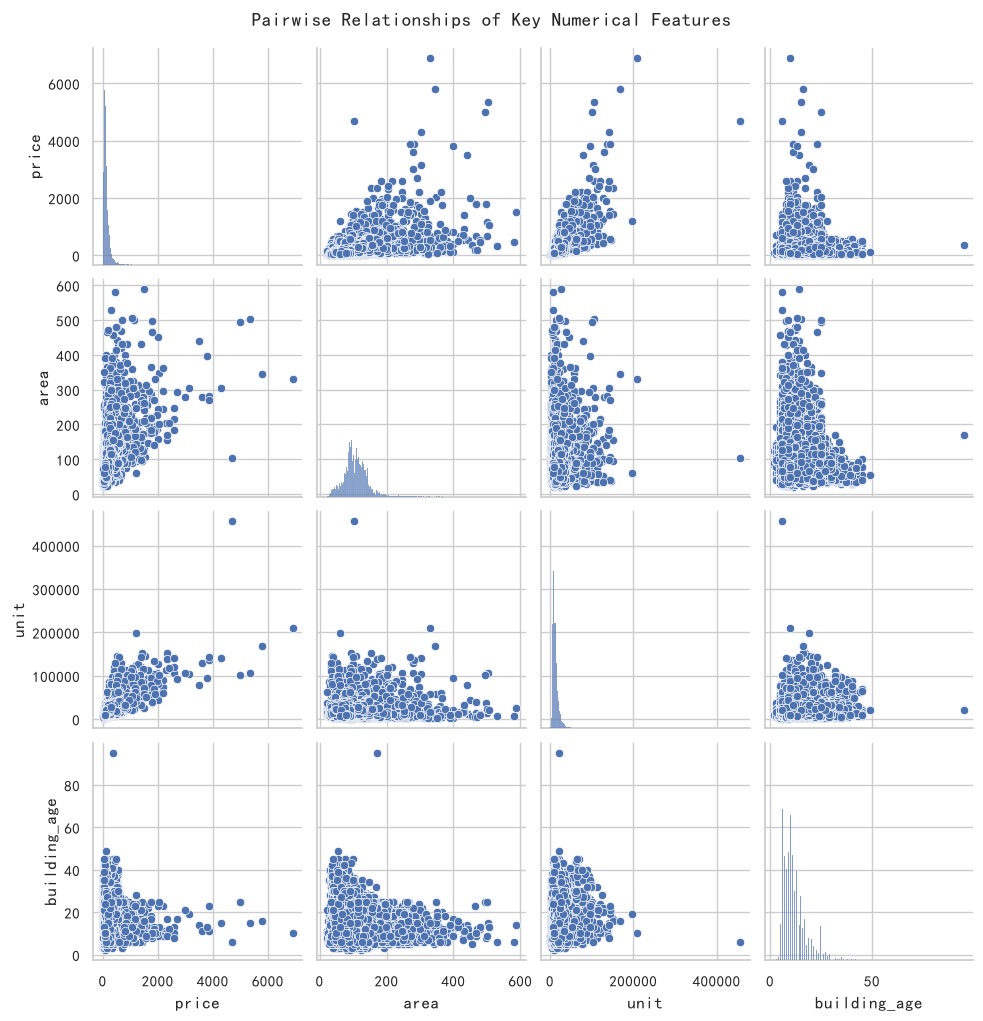

In [193]:
# Select relevant numerical columns
cols = ['price', 'area', 'unit', 'building_age']
sns.pairplot(df_house[cols])
plt.suptitle('Pairwise Relationships of Key Numerical Features', y=1.02, fontsize=14)
plt.show()